In [1]:
# from multiprocessing import Pool
# from rdkit.Chem import AllChem
# from rdkit import Chem
# import pandas as pd
# import numpy as np
# from tqdm import tqdm
# import pickle
# import gzip
# import os

# # Given (NAME, SMILES) create 3D conformer
# def generate_3d_conformer(input_list):
#     ID, smi = input_list
#     mol = Chem.MolFromSmiles(smi)
#     mol = Chem.AddHs(mol)
#     params = AllChem.ETKDGv3()
#     params.randomSeed = 42 
#     status = AllChem.EmbedMolecule(mol, params=params)
#     if status != 0:
#         return [ID, None]
#     AllChem.UFFOptimizeMolecule(mol)
#     return [ID, mol]

# # Load compound info
# data = pd.read_csv(os.path.join("..", "processed", "enamine_REAL_characterization", "enamine_REAL.tsv"), sep='\t')
# ID_TO_SMILES = {i: j for i,j in zip(data['id'], data['smiles'])}
# IDs = sorted(ID_TO_SMILES)

# # Prepare input list
# input_list = [[id, ID_TO_SMILES[id]]for id in IDs]

# # Create output directories 
# OUTPATH = "../processed/enamine_REAL_characterization"
# os.makedirs(os.path.join(OUTPATH), exist_ok=True)

# input_list = input_list[:10000]

# # Run conformer generation - parallelized
# N_WORKERS = 16
# with Pool(N_WORKERS) as pool:
#     mols = list(tqdm(pool.imap(generate_3d_conformer, input_list), total=len(input_list)))

# # Convert to dict
# mols = dict(mols)

# # Dump results
# with gzip.open(os.path.join(OUTPATH, "mols.pkl.gz"), "wb") as f:
#     pickle.dump(mols, f, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
import pandas as pd
import random
import pickle
import gzip
import os

random.seed(42)
# root = os.path.dirname(os.path.abspath(__file__))
root = "."

### FIRST STEP - CHECK WHICH CONFORMATIONS FAILED

# Caution: this script is run from herbert and takes data from norrsken-gpu-wsl

# Load id to mol dict
PATH_TO_CONFORMATIONS = os.path.join(root, "..", "..", "..", "Documents_GPU", "mtb-targeted-protein-degradation", "processed", "enamine_REAL_characterization", 'mols_old.pkl.gz')
with gzip.open(PATH_TO_CONFORMATIONS, "rb") as f:
    mols = pickle.load(f)

print(f"Total number of molecules: {len(mols)}")
# assert len(mols) == 9557695

# Select molecules that failed
failed_mols = [i for i in mols if mols[i] == None]
print(f"Total number of failed molecules: {len(failed_mols)}")

# Save failed molecules
PATH_TO_FAILED = os.path.join(root, "..", "processed", "enamine_REAL_characterization", "failed_REAL.csv")
with open(PATH_TO_FAILED, "w") as out:
    out.write("\n".join(failed_mols))

### SECOND STEP - GENERATE A RANDOM SAMPLE OF 10K REAL COMPOUNDS

# Get IDs
IDs = sorted(mols)

# Sample 10k compounds
sample = random.sample([i for i in IDs if i not in failed_mols], 10000)
print(f"Total number of sampled compounds: {len(sample)}")

# Save results
PATH_TO_SAMPLE = os.path.join(root, "..", "processed", "enamine_REAL_characterization", "random_sample_REAL.csv")
with open(PATH_TO_SAMPLE, "w") as out:
    out.write("\n".join(sample))

Total number of molecules: 100000
Total number of failed molecules: 37
Total number of sampled compounds: 10000


In [5]:
s = ID_TO_SMILES['m_11____13657954____22023496']

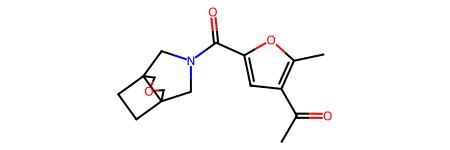

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem
Chem.MolFromSmiles(s)

In [11]:
# Given (NAME, SMILES) create 3D conformer
def generate_3d_conformer(input_list):
    ID, smi = input_list
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 42 
    status = AllChem.EmbedMolecule(mol, params=params)
    if status != 0:
        return [ID, None]
    AllChem.UFFOptimizeMolecule(mol)
    return [ID, mol]

In [13]:
generate_3d_conformer(["a", s])

['a', None]